In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [27]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
RAW_DATA = PROJECT_ROOT / "data" / "raw"
REFERENCE_DATA = PROJECT_ROOT / "data" / "reference"

print("Project Root:", PROJECT_ROOT)
print("Raw Data:", RAW_DATA)
print("Reference Data:", REFERENCE_DATA)

Project Root: d:\FullStackProjects\Banao_Ai_Assignment\TASK_1\vireo-refund-intelligence
Raw Data: d:\FullStackProjects\Banao_Ai_Assignment\TASK_1\vireo-refund-intelligence\data\raw
Reference Data: d:\FullStackProjects\Banao_Ai_Assignment\TASK_1\vireo-refund-intelligence\data\reference


In [28]:
tickets = pd.read_csv(RAW_DATA / "tickets.csv")
agents = pd.read_csv(RAW_DATA / "agents.csv")
orders = pd.read_csv(RAW_DATA / "orders.csv")
customers = pd.read_csv(RAW_DATA / "customers.csv")
products = pd.read_csv(RAW_DATA / "products.csv")

In [29]:
#rows
datasets = {
    "tickets": tickets,
    "agents": agents,
    "orders": orders,
    "customers": customers,
    "products": products
}
for name, df in datasets.items():
    print(f"{name:12} → Rows: {df.shape[0]}, Columns: {df.shape[1]}")

tickets      → Rows: 12238, Columns: 21
agents       → Rows: 44, Columns: 8
orders       → Rows: 15000, Columns: 8
customers    → Rows: 9500, Columns: 6
products     → Rows: 14, Columns: 7


In [30]:
#Columns
for name, df in datasets.items():
    print("\n" + "=" * 60)
    print(name.upper())
    print("=" * 60)
    print(df.columns.tolist())


TICKETS
['ticket_id', 'created_at', 'first_response_at', 'resolved_at', 'status', 'channel', 'customer_id', 'order_id', 'product_sku', 'category', 'priority', 'assigned_team', 'agent_id', 'transfers', 'csat_score', 'refund_amount_inr', 'refund_reason_code', 'replacement_issued', 'customer_message', 'agent_notes', 'source_system']

AGENTS
['agent_id', 'name', 'site', 'team', 'shift', 'tier', 'from_date', 'to_date']

ORDERS
['order_id', 'customer_id', 'sku', 'order_date', 'channel', 'qty', 'order_value_inr', 'lot_code']

CUSTOMERS
['customer_id', 'name', 'city', 'state', 'signup_date', 'care_plus']

PRODUCTS
['sku', 'product_name', 'family', 'launch_date', 'unit_cost_inr', 'retail_price_inr', 'warranty_months']


In [31]:
for name, df in datasets.items():
    print("\n" + "=" * 60)
    print(name.upper())
    print("=" * 60)
    display(df.head())


TICKETS


,ticket_id,created_at,first_response_at,resolved_at,status,channel,customer_id,order_id,product_sku,category,...,assigned_team,agent_id,transfers,csat_score,refund_amount_inr,refund_reason_code,replacement_issued,customer_message,agent_notes,source_system
0,TK-240001,2025-01-01 09:17,2025-01-01 09:20,2025-01-02 09:37,resolved,chat,C103445,VR894176,VA-EB-AIR,Returns & Refunds,...,Returns Desk,A3038,0,5.0,NaN,NaN,N,sir ji\npickup scheduled but no one showed up\...,1. Pickup missed\n2. Checked pickup AWB\n3. rf...,legacy_fd
1,TK-240002,2025-01-01 09:45,2025-01-01 10:18,2025-01-01 10:30,resolved,voice,C108122,VR897663,VA-SW-FIT,Account & Login,...,Voice Frontline,A3023,0,3.0,NaN,NaN,N,Really frustrating. Order VR897663 (my Nexa Fi...,reported: unable to log in. chk otp logs. numb...,helpdesk
2,TK-240002,2025-01-01 09:45,2025-01-01 10:18,2025-01-01 10:30,resolved,voice,C108122,VR897663,VA-SW-FIT,Account & Login,...,Voice Frontline,A3023,0,3.0,NaN,NaN,N,Really frustrating. Order VR897663 (my Nexa Fi...,reported: unable to log in. chk otp logs. numb...,legacy_fd
3,TK-240003,2025-01-01 19:04,2025-01-01 21:26,2025-01-04 02:53,resolved,email,C102158,VR886967,VA-HP-ST2,Warranty & Repair,...,Escalations & Warranty,A3040,0,4.0,900.0,GW-OTHER,N,"Dear Sir/Madam,\n\nI am writing with reference...",cx ok,helpdesk
4,TK-240003,2025-01-01 19:04,2025-01-01 21:26,2025-01-04 02:53,resolved,email,C102158,VR886967,VA-HP-ST2,Warranty & Repair,...,Escalations & Warranty,A3040,0,4.0,90000.0,GW-OTHER,N,"Dear Sir/Madam,\n\nI am writing with reference...",cx ok,legacy_fd



AGENTS


,agent_id,name,site,team,shift,tier,from_date,to_date
0,A3001,Suresh Kaur,Indore,Chat Frontline,Night,1,2024-03-17,NaN
1,A3002,Steven Ansari,Indore,Chat Frontline,Night,1,2023-11-29,NaN
2,A3003,Komal Singh,Indore,Chat Frontline,Night,1,2023-11-12,NaN
3,A3004,Geeta Dutta,Bengaluru,Chat Frontline,Day,1,2022-08-25,NaN
4,A3005,Payal Bhatia,Indore,Chat Frontline,Day,1,2023-11-13,NaN



ORDERS


,order_id,customer_id,sku,order_date,channel,qty,order_value_inr,lot_code
0,VR884750,C104051,VA-AC-CH65,2024-06-15,Amazon,2,2998,CH65-2405-3
1,VR886282,C103775,VA-AC-CBL,2024-06-15,Amazon,1,359,CBL-2405-2
2,VR888631,C104948,VA-EB-PL1,2024-06-15,vireo.in,1,1999,PL1-2403-3
3,VR891388,C100563,VA-SP-ORB,2024-06-15,Flipkart,1,5399,ORB-2404-4
4,VR892331,C102056,VA-EB-PL1,2024-06-15,Amazon,1,2499,PL1-2404-3



CUSTOMERS


,customer_id,name,city,state,signup_date,care_plus
0,C100000,Lobsang Khan,Bhubaneswar,OR,2024-10-13,N
1,C100001,Ritika Banerjee,Noida,UP,2023-05-15,N
2,C100002,Ritika Sharma,Dehradun,UK,2024-05-03,N
3,C100003,Om Pereira,Mumbai,MH,2023-02-24,N
4,C100004,Pranav Mukherjee,Kochi,KL,2024-04-08,N



PRODUCTS


,sku,product_name,family,launch_date,unit_cost_inr,retail_price_inr,warranty_months
0,VA-EB-PL2,Pulse 2 True Wireless Earbuds,earbuds,2025-07-15,1480,3499,12
1,VA-EB-PL1,Pulse True Wireless Earbuds,earbuds,2024-03-01,1120,2499,12
2,VA-EB-AIR,AirLite Earbuds,earbuds,2024-09-10,760,1799,12
3,VA-HP-ST3,Strata 3 Over-Ear Headphones,headphones,2024-11-20,2650,6999,12
4,VA-HP-ST2,Strata 2 Over-Ear Headphones,headphones,2023-10-01,2100,4999,12


In [32]:
# DATA TPES 
for name, df in datasets.items():
    print("\n" + "=" * 60)
    print(name.upper())
    print("=" * 60)
    print(df.dtypes)


TICKETS
ticket_id                 str
created_at                str
first_response_at         str
resolved_at               str
status                    str
channel                   str
customer_id               str
order_id                  str
product_sku               str
category                  str
priority                  str
assigned_team             str
agent_id                  str
transfers               int64
csat_score            float64
refund_amount_inr     float64
refund_reason_code        str
replacement_issued        str
customer_message          str
agent_notes               str
source_system             str
dtype: object

AGENTS
agent_id         str
name             str
site             str
team             str
shift            str
tier           int64
from_date        str
to_date      float64
dtype: object

ORDERS
order_id             str
customer_id          str
sku                  str
order_date           str
channel              str
qty                int64

In [33]:
#Missing Values
for name, df in datasets.items():
    print("\n" + "=" * 60)
    print(name.upper())
    print("=" * 60)

    missing = df.isnull().sum()
    print(missing[missing > 0])


TICKETS
resolved_at            622
order_id              4127
csat_score            6729
refund_amount_inr     9773
refund_reason_code    9773
dtype: int64

AGENTS
to_date    44
dtype: int64

ORDERS
Series([], dtype: int64)

CUSTOMERS
Series([], dtype: int64)

PRODUCTS
Series([], dtype: int64)


In [34]:
# Duplicate Records
for name, df in datasets.items():
    print("\n" + "=" * 60)
    print(name.upper())
    print("=" * 60)
    print("Duplicate rows:", df.duplicated().sum())


TICKETS
Duplicate rows: 0

AGENTS
Duplicate rows: 0

ORDERS


Duplicate rows: 0

CUSTOMERS
Duplicate rows: 0

PRODUCTS
Duplicate rows: 0


In [35]:
# Basic Statistics
for name, df in datasets.items():
    print("\n" + "=" * 60)
    print(name.upper())
    print("=" * 60)
    display(df.describe())


TICKETS


,transfers,csat_score,refund_amount_inr
count,12238.000000,5509.000000,2.465000e+03
mean,0.094787,3.493738,9.335663e+04
std,0.324184,0.959135,1.866372e+05
min,0.000000,1.000000,3.200000e+01
25%,0.000000,3.000000,1.799000e+03
50%,0.000000,4.000000,3.499000e+03
75%,0.000000,4.000000,1.000000e+05
max,2.000000,5.000000,1.399800e+06



AGENTS


,tier,to_date
count,44.000000,0.0
mean,1.136364,NaN
std,0.347142,NaN
min,1.000000,NaN
25%,1.000000,NaN
50%,1.000000,NaN
75%,1.000000,NaN
max,2.000000,NaN



ORDERS


,qty,order_value_inr
count,15000.000000,15000.000000
mean,1.068867,3564.566467
std,0.253236,2059.073890
min,1.000000,319.000000
25%,1.000000,1999.000000
50%,1.000000,3149.000000
75%,1.000000,4999.000000
max,2.000000,13998.000000



CUSTOMERS


,customer_id,name,city,state,signup_date,care_plus
count,9500,9500,9500,9500,9500,9500
unique,9500,4585,30,20,901,2
top,C100000,Ritika Sheikh,Guwahati,MH,2022-08-23,N
freq,1,9,344,1259,24,6524



PRODUCTS


,unit_cost_inr,retail_price_inr,warranty_months
count,14.000000,14.000000,14.000000
mean,1317.857143,3306.142857,10.714286
std,821.913139,2182.258634,2.554892
min,90.000000,399.000000,6.000000
25%,655.000000,1574.000000,12.000000
50%,1050.000000,2499.000000,12.000000
75%,2050.000000,4999.000000,12.000000
max,2650.000000,6999.000000,12.000000


In [36]:
# README chaeck 
readme_path = REFERENCE_DATA / "README.txt"

with open(readme_path, "r", encoding="utf-8") as file:
    readme_text = file.read()

print(readme_text)

VIREO AUDIO — SUPPORT DATA PACK

tickets.csv          Support tickets, 1 Jan 2025 – 30 Jun 2026. One row per ticket as exported.
                     Timestamps are as displayed in the helpdesk (IST).
  ticket_id            Helpdesk ticket number
  created_at           Ticket creation
  first_response_at    First human agent reply
  resolved_at          Resolution (blank if open/pending). For legacy tickets this was
                       reconstructed from the event log.
  status               resolved | closed (auto-closed, no customer reply) | open | pending
  channel              chat | email | voice | social
  customer_id          Key into customers.csv
  order_id             Key into orders.csv. Blank when the customer did not quote it.
                       customer_id + product_sku is the fallback join.
  product_sku          Key into products.csv
  category             Category tag set by the intake bot at creation; agents may re-tag on closure
  priority             Low | No

In [37]:
readme_path = REFERENCE_DATA / "README.txt"

with open(readme_path, "r", encoding="utf-8") as file:
    readme_text = file.read()

print(readme_text)

VIREO AUDIO — SUPPORT DATA PACK

tickets.csv          Support tickets, 1 Jan 2025 – 30 Jun 2026. One row per ticket as exported.
                     Timestamps are as displayed in the helpdesk (IST).
  ticket_id            Helpdesk ticket number
  created_at           Ticket creation
  first_response_at    First human agent reply
  resolved_at          Resolution (blank if open/pending). For legacy tickets this was
                       reconstructed from the event log.
  status               resolved | closed (auto-closed, no customer reply) | open | pending
  channel              chat | email | voice | social
  customer_id          Key into customers.csv
  order_id             Key into orders.csv. Blank when the customer did not quote it.
                       customer_id + product_sku is the fallback join.
  product_sku          Key into products.csv
  category             Category tag set by the intake bot at creation; agents may re-tag on closure
  priority             Low | No

In [38]:
#Email thread
email_path = REFERENCE_DATA / "email-thread.txt"

with open(email_path, "r", encoding="utf-8") as file:
    email_text = file.read()

print(email_text)

EMAIL THREAD — Vireo Audio — support tickets (Set C)
Messages exchanged before this pack was sent. Provided as-is.

From: Arjun Mehta, Finance Controller, Vireo Audio
To: Kabir Nanda, Account Lead (our side)
Cc: Priya Raman; Neha Kulkarni; Sameer Qureshi
Date: Mon 7 Sep 2026, 11:05
Subject: Refund summary

Kabir - monthly refunds by reason code and by agent. Who, how much, what for. My export
sums to well over a crore a quarter which cannot be right and is exactly why I want
someone else's eyes on it.

------------------------------------------------------------------------

From: Sameer Qureshi, Helpdesk Administrator (IT), Vireo Audio
To: Kabir Nanda, Account Lead (our side)
Cc: Priya Raman; Arjun Mehta; Neha Kulkarni
Date: Mon 7 Sep 2026, 16:10
Subject: Re: Refund summary

Files attached. Two things. The legacy Freshdesk rows store money the way Freshdesk
stored money, and I believe Finance reconciles that on their side - I never changed it.
Reason codes come from a dropdown; the fi

In [39]:
# Submission Form
submission_path = REFERENCE_DATA / "submission-form.md"

with open(submission_path, "r", encoding="utf-8") as file:
    submission_text = file.read()

print(submission_text) 

In [40]:
#

# Business Understanding

## Business Question

Finance wants a monthly refund summary showing:

- Refund amount
- Refund reason code
- Resolving agent
- Monthly trend

The main objective is to reconcile the refund totals and understand what is driving refunds.

## Important Business Context

- Refund reason codes are selected by the resolving agent.
- Returns Desk processes the large majority of refunds by design.
- Refunds and replacements must not both be given for the same order.
- Goodwill credits are capped at Rs 500 per ticket and require Team Lead approval.
- First-response SLA breaches automatically issue a Rs 350 store credit.
- Legacy Freshdesk tickets may appear under both legacy and current systems because of migration/re-import.
- Legacy and current systems store monetary values differently.
- Current helpdesk monetary values are in rupees.
- Agents can have multiple roster records because assignments can change over time.
- Tier 2 agents should not be compared with Tier 1 agents on volume metrics.
- Blank CSAT means no response and must be excluded from averages.

## Initial Investigation Questions

1. What is the actual total refund amount?
2. Is Finance's refund total consistent with the support data?
3. Are legacy monetary values causing the large discrepancy?
4. Are duplicate/re-imported tickets inflating refunds?
5. Which refund reason codes contribute most to refund value?
6. How does refund value change month by month?
7. Which agents are associated with refunds?
8. Are refunds and replacements both occurring for the same order?
9. Are there unusual refund patterns that need investigation?
10. Can customer messages and agent notes help identify the actual refund reason?

#Fixing the "1 Crore vs 11 Lakh"

In [41]:
# Copy this into your Jupyter Notebook cell

print("--- BEFORE CLEANING ---")
print(f"Total rows: {tickets.shape[0]}")
print(f"Total refund amount: ₹ {tickets['refund_amount_inr'].sum():,.2f}")

# 1. Convert to numeric and replace missing refunds (NaN) with 0
tickets['refund_amount_inr'] = pd.to_numeric(tickets['refund_amount_inr'], errors='coerce').fillna(0)

# 2. The Currency Bug: 'legacy_fd' stored money in Paise. Divide by 100 to get Rupees.
mask_legacy = tickets['source_system'] == 'legacy_fd'
tickets.loc[mask_legacy, 'refund_amount_inr'] = tickets.loc[mask_legacy, 'refund_amount_inr'] / 100

# 3. The Duplicate Bug: System migration created duplicate tickets. Keep 'helpdesk'.
tickets = tickets.sort_values(by=['ticket_id', 'source_system'])
tickets = tickets.drop_duplicates(subset=['ticket_id'], keep='first')

print("\n--- AFTER CLEANING ---")
print(f"Total rows: {tickets.shape[0]}")
print(f"Total refund amount: ₹ {tickets['refund_amount_inr'].sum():,.2f}")

--- BEFORE CLEANING ---
Total rows: 12238
Total refund amount: ₹ 230,124,081.00

--- AFTER CLEANING ---
Total rows: 11600
Total refund amount: ₹ 6,709,932.00


In [42]:

merged_df = tickets.merge(
    agents[['agent_id', 'name', 'team', 'tier']].drop_duplicates(subset=['agent_id']), 
    on='agent_id', 
    how='left'
)

print("Merged Data Columns:")
print(merged_df.columns.tolist())


team_refunds = merged_df.groupby('team')['refund_amount_inr'].sum().sort_values(ascending=False)
print("\nTotal Refunds by Team:")
print(team_refunds)

Merged Data Columns:
['ticket_id', 'created_at', 'first_response_at', 'resolved_at', 'status', 'channel', 'customer_id', 'order_id', 'product_sku', 'category', 'priority', 'assigned_team', 'agent_id', 'transfers', 'csat_score', 'refund_amount_inr', 'refund_reason_code', 'replacement_issued', 'customer_message', 'agent_notes', 'source_system', 'name', 'team', 'tier']

Total Refunds by Team:
team
Returns Desk              1692666.0
Billing                   1579977.0
Chat Frontline            1165339.0
Logistics                 1111749.0
Email Frontline            564316.0
Escalations & Warranty     298735.0
Voice Frontline            297150.0
Name: refund_amount_inr, dtype: float64


--- REFUNDS BY REASON CODE ---
                    Tickets_Count  Total_Refund_INR
refund_reason_code                                 
GW-OTHER                      991         2907036.0
RETURN-QC-OK                  452         1181386.0
DUP-PAYMENT                   321          884586.0
CANCEL                        222          612950.0
DOA-REPL                      147          471190.0
WTY-BUYBACK                    89          289154.0
PRICE-ADJ                      71          207073.0
LOST-TRANSIT                   47          156557.0


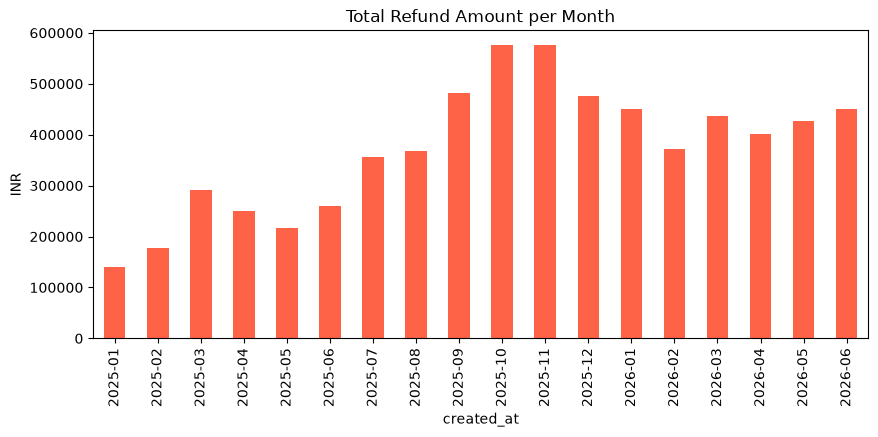

In [43]:
# 1. Check how many times each reason code was used for tickets with actual refunds
refund_tickets = merged_df[merged_df['refund_amount_inr'] > 0]
reason_counts = refund_tickets.groupby('refund_reason_code').agg(
    Tickets_Count=('ticket_id', 'count'),
    Total_Refund_INR=('refund_amount_inr', 'sum')
).sort_values(by='Tickets_Count', ascending=False)

print("--- REFUNDS BY REASON CODE ---")
print(reason_counts)

# 2. Check Priya's claim: Did refunds spike in Q4?
merged_df['created_at'] = pd.to_datetime(merged_df['created_at'])
monthly_refunds = merged_df.groupby(merged_df['created_at'].dt.to_period("M"))['refund_amount_inr'].sum()

import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
monthly_refunds.plot(kind='bar', color='tomato')
plt.title('Total Refund Amount per Month')
plt.ylabel('INR')
plt.show()

In [44]:
import pandas as pd
import re

# 1. Re-create merged_df (Merging cleaned tickets with agents)
merged_df = tickets.merge(
    agents[['agent_id', 'name', 'team', 'tier']].drop_duplicates(subset=['agent_id']), 
    on='agent_id', 
    how='left'
)

# 2. Define the Deterministic NLP Classification Engine
def smart_classify_reason(row):
    text = str(row['customer_message']).lower() + " " + str(row['agent_notes']).lower()
    
    if re.search(r'\b(doa|dead|not working|broken|defective|right out of the box|won\'t turn on)\b', text):
        return 'DOA-REPL'
    elif re.search(r'\b(lost|not delivered|transit|tracking|missing|never received)\b', text):
        return 'LOST-TRANSIT'
    elif re.search(r'\b(duplicate|charged twice|double|two times|charged me twice)\b', text):
        return 'DUP-PAYMENT'
    elif re.search(r'\b(cancel|changed mind|mistake|don\'t want)\b', text):
        return 'CANCEL'
    elif re.search(r'\b(price|coupon|discount|cheaper|adjustment)\b', text):
        return 'PRICE-ADJ'
    elif re.search(r'\b(warranty|buyback|buy back)\b', text):
        return 'WTY-BUYBACK'
    elif re.search(r'\b(return|qc|quality|sound quality|unhappy)\b', text):
        return 'RETURN-QC-OK'
    
    return 'GW-OTHER'

# 3. Apply the engine to GW-OTHER tickets
mask = (merged_df['refund_reason_code'] == 'GW-OTHER') & (merged_df['refund_amount_inr'] > 0)
merged_df['corrected_reason_code'] = merged_df['refund_reason_code'] # Default to original
merged_df.loc[mask, 'corrected_reason_code'] = merged_df[mask].apply(smart_classify_reason, axis=1)

# 4. Show the Results
old_gw_count = mask.sum()
new_gw_count = (merged_df['corrected_reason_code'] == 'GW-OTHER').sum()
resolved_tickets = old_gw_count - new_gw_count

print(f"Successfully re-classified {resolved_tickets} tickets out of {old_gw_count} GW-OTHER tickets.")

print("\n--- NEW CORRECTED REFUND REASONS ---")
new_distribution = merged_df[merged_df['refund_amount_inr'] > 0].groupby('corrected_reason_code').agg(
    Tickets_Count=('ticket_id', 'count'),
    Total_Refund_INR=('refund_amount_inr', 'sum')
).sort_values(by='Tickets_Count', ascending=False)
print(new_distribution)

Successfully re-classified 533 tickets out of 991 GW-OTHER tickets.

--- NEW CORRECTED REFUND REASONS ---
                       Tickets_Count  Total_Refund_INR
corrected_reason_code                                 
RETURN-QC-OK                     605         1653866.0
GW-OTHER                         458         1321173.0
DUP-PAYMENT                      389         1069469.0
CANCEL                           326          930021.0
DOA-REPL                         190          604101.0
LOST-TRANSIT                     142          457594.0
WTY-BUYBACK                      116          377933.0
PRICE-ADJ                        114          295775.0
